In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle

import time

from sklearn.preprocessing import LabelEncoder
from data_load_utils import load_image, load_data, create_data_frame

import PIL
from PIL import Image

import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler
from torchvision.datasets import ImageFolder
from torchvision import transforms

In [2]:
from torchvision.models import ResNet50_Weights

## Loading & Preparing Data for ResNet50

In [3]:
training_dir = "./data/train"
testing_dir = "./data/test"

In [39]:
weights = ResNet50_Weights.IMAGENET1K_V2

In [5]:
transform = weights.transforms()

In [6]:
train_dataset = ImageFolder(root=training_dir, transform=transform)

In [7]:
labels = [label for _, label in train_dataset.samples]

In [34]:
counts = {}
for label in labels:
    try:
        counts[label] += 1
    except:
        counts[label] = 1    

In [47]:
class_weights = [v for v in counts.values()]

In [48]:
class_weights

[3995, 436, 4097, 7215, 4965, 4830, 3171]

In [49]:
sample_weights = [0] *len(train_dataset)

In [51]:
for i, (data, label) in enumerate(train_dataset):
    class_weight = class_weights[label]
    sample_weights[i] = class_weight

In [54]:
sampler = WeightedRandomSampler(sample_weights, num_samples = len(sample_weights), replacement = True)

In [56]:
train_loader = DataLoader(train_dataset, batch_size = 10, sampler = sampler)

Inspecting Training Data Distribution

In [18]:
from collections import Counter

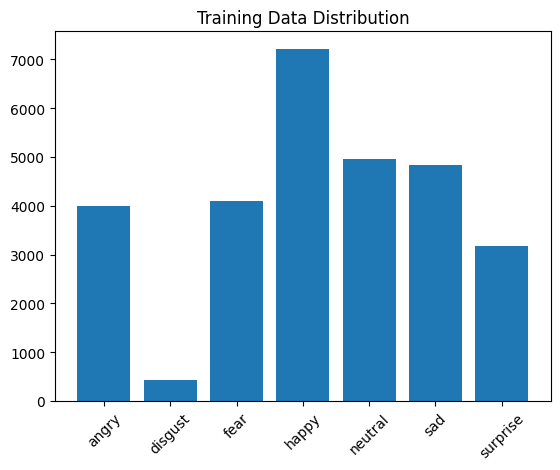

In [25]:
names = train_dataset.classes
counts = [class_counts[i] for i in range(len(names))]

plt.bar(names, counts)
plt.title("Training Data Distribution")
plt.xticks(rotation=45)
plt.savefig("./graphics/Training_Data_Distribution")
plt.show()

## Loading & Training ResNet50

In [57]:
model = torchvision.models.resnet50(weights = weights, progress = True)

In [58]:
for param in model.parameters():
    param.requires_grad = False

In [59]:
num_ftrs = model.fc.in_features

In [60]:
model.fc = nn.Linear(num_ftrs, 7)

In [61]:
model = model.to("cuda")

In [62]:
criterion = nn.CrossEntropyLoss().to("cuda")
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

In [63]:
losses = []
scores = {}
epoch_count = 0

In [64]:
epochs = 15

start_time = time.time()

for epoch in range(epochs):
    model.train()
    corrects = 0
    wrongs = 0 
    running_loss = 0
    for b, (X_train, y_train) in enumerate(train_loader):
        X_train = X_train.to("cuda")
        y_train = y_train.to("cuda")
        batch = b+1
        y_pred = model(X_train)
        loss = criterion(y_pred, y_train)

        predicted = torch.argmax(y_pred, dim = 1)

        corrects += (predicted == y_train).sum().item()
        wrongs += (predicted != y_train).sum().item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        if b%100 == 0:
            print(f"Epoch: {epoch}/{epochs} Batch: {batch} Current Loss: {running_loss/batch}")
    
    scores[epoch_count] = {
        "corrects": corrects,
        "wrongs": wrongs,
        "accuracy": corrects/(wrongs+corrects),
        "loss": running_loss/batch
    }
    epoch_count += 1
    print(f"Epoch: {epoch}. Current Accuracy: {corrects/(wrongs+corrects)}")
    losses.append(running_loss/batch)

end_time = time.time()
total_time = (end_time-start_time)/60
print(f"Training took {total_time} minutes")
        

Epoch: 0/10 Batch: 1 Current Loss: 1.9110538959503174
Epoch: 0/10 Batch: 101 Current Loss: 1.6723418920347006
Epoch: 0/10 Batch: 201 Current Loss: 1.6121444642840332
Epoch: 0/10 Batch: 301 Current Loss: 1.5925536587388809
Epoch: 0/10 Batch: 401 Current Loss: 1.5796681496865137
Epoch: 0/10 Batch: 501 Current Loss: 1.570020869582475
Epoch: 0/10 Batch: 601 Current Loss: 1.561926019965313
Epoch: 0/10 Batch: 701 Current Loss: 1.5542939119094108
Epoch: 0/10 Batch: 801 Current Loss: 1.5486630339747511
Epoch: 0/10 Batch: 901 Current Loss: 1.5383962935268813
Epoch: 0/10 Batch: 1001 Current Loss: 1.5328496152108961
Epoch: 0/10 Batch: 1101 Current Loss: 1.5264032225409603
Epoch: 0/10 Batch: 1201 Current Loss: 1.5174362929933374
Epoch: 0/10 Batch: 1301 Current Loss: 1.5085898053636926
Epoch: 0/10 Batch: 1401 Current Loss: 1.5049164298600082
Epoch: 0/10 Batch: 1501 Current Loss: 1.5025280879228453
Epoch: 0/10 Batch: 1601 Current Loss: 1.49875911953001
Epoch: 0/10 Batch: 1701 Current Loss: 1.4944428

In [95]:
#Saving Model
torch.save(model, "./models/resnet50_fine_tuned_single_fc_weighed_classes.pth")

In [96]:
#Saving Model Params in order to make continued training possible
torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict()
}, "./models/resnet50_fine_tuned_single_fc_weighed_classes_checkpoint.pth")

In [97]:
#Saving Scores Dict in order to keep track of model improvements in case of continued training
with open("./models/resnet_50_fine_tuned_single_fc_weighed_classes_scores.pkl", "wb") as f:
    pickle.dump(scores, f)

In [92]:
accuracies = []
for v in scores.values():
    accuracies.append(v["accuracy"])

In [93]:
accuracies

[0.4400013932913024,
 0.47911804660559404,
 0.49141384234908914,
 0.4980319760353896,
 0.5005747326622314,
 0.5072973631962102,
 0.5067748789578181,
 0.5102581072137657,
 0.5101884426486467,
 0.5100142812358494]

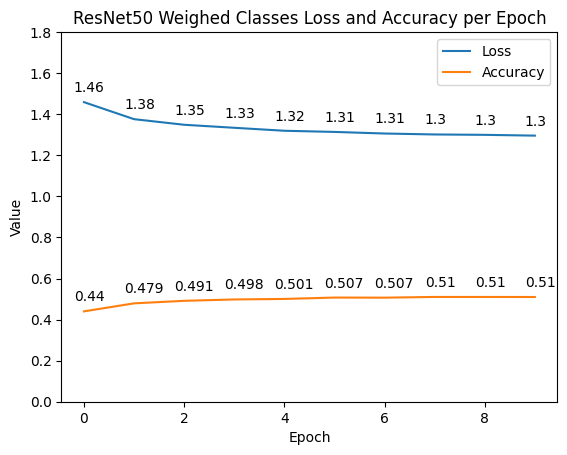

In [94]:
plt.plot(range(len(losses)), losses, label = "Loss")
plt.plot(range(len(accuracies)), accuracies, label = "Accuracy")
for i, v in enumerate(losses):
    plt.text(i -0.2, v+0.05, f"{v:.3}")

for i, v in enumerate(accuracies):
    plt.text(i-0.2, v+0.05, f"{v:.3}")
plt.ylim(0,1.8)
plt.legend()
plt.title("ResNet50 Weighed Classes Loss and Accuracy per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.savefig("./graphics/ResNet50_weighted_classes_Loss_Accuracy")
plt.show()

## Evaluating on testing Data

In [65]:
testing_data = ImageFolder(root = testing_dir, transform = transform)

In [69]:
testing_data.samples[0]

('./data/test\\angry\\PrivateTest_10131363.jpg', 0)

In [70]:
testing_loader = DataLoader(testing_data, batch_size = 10, shuffle = False)

In [76]:
predictions = []

In [77]:
model.eval()
with torch.no_grad():
    for X_test, y_test in testing_loader:
        X_test = X_test.to("cuda")
        y_test = y_test.to("cuda")
        y_pred = model(X_test)
        preds = torch.argmax(y_pred, dim = 1)
        predictions.extend(preds.item())
        

In [83]:
actual = [label for _, label in testing_data]

In [86]:
len(actual)

7178

In [87]:
len(predictions)

7178

In [89]:
corrects = 0
for i, v in enumerate(predictions):
    if v == actual[i]:
        corrects += 1

In [90]:
corrects/len(actual)

0.39746447478406244